### Imports and Configuration

In [1]:
from pipeline_utils import make_case2_paths
import pandas as pd
import numpy as np

CATEGORIES = [f"cat{i}" for i in range(1, 6)]
MODEL_LABELS = {"ResNet18": "ResNet18", "RandomForest": "Random Forest"}
MODEL_COLORS = {"ResNet18": "#0072B2", "RandomForest": "#fc8d62"}
METRIC_LABELS = {
    "test_macro_precision": "Precision",
    "test_macro_recall": "Recall",
    "test_macro_f1": "F1",
    "test_balanced_accuracy": "Balanced Acc.",
}
# cat1 .. cat5, in the order the classifier scale actually runs -- swapped from the
# SHAP library's own class ordering, which sorts by total contribution instead.
CLASS_ORDER = ["Highly Resistant", "Resistant", "Intermediate", "Sensitive", "Highly Sensitive"]
CLASS_COLORS = ["#0072B2", "#56B4E9", "#999999", "#009E73", "#E69F00"]
CLASS_LABELS = [f"Cat_{i + 1}: {name}" for i, name in enumerate(CLASS_ORDER)]

# Configure paths
paths = make_case2_paths()

PROJECT_DIR = paths["project"]
PROC_DIR = paths["proc"]
RESULTS_DIR = paths["results"]

print(f"Project directory: {PROJECT_DIR}")
print(f"Processed data directory: {PROC_DIR}")
print(f"Results directory: {RESULTS_DIR}")

# Input files -- both models were trained on the same 5-fold CV assignment
# (data/procdata/2_drugSensitivity/ml_cv_fold_assignment.csv), so their
# per-fold and pooled out-of-fold results are directly comparable.
resnet_dir = PROC_DIR / "ml_model" / "resnet18"
rf_dir = PROC_DIR / "ml_model" / "random_forest"

resnet_fold_results = pd.read_csv(resnet_dir / "resnet18_cv_fold_results.csv")
resnet_fold_results.insert(0, "model", "ResNet18")
rf_fold_results = pd.read_csv(rf_dir / "rf_cv_fold_results.csv")
rf_fold_results.insert(0, "model", "RandomForest")

resnet_cm = pd.read_csv(resnet_dir / "resnet18_cv_confusion_matrix.csv", index_col=0)
rf_cm = pd.read_csv(rf_dir / "rf_cv_confusion_matrix.csv", index_col=0)

resnet_pred = pd.read_csv(resnet_dir / "resnet18_cv_predictions.csv")
rf_pred = pd.read_csv(rf_dir / "rf_cv_predictions.csv")

# Per-class SHAP magnitudes from the final RF model (see 4-ml_randomforest.ipynb) --
# already sorted by total mean(|SHAP|), descending.
shap_by_class_df = pd.read_csv(rf_dir / "rf_final_shap_by_class.csv", index_col="feature")

print(f"ResNet18 fold results: {resnet_dir / 'resnet18_cv_fold_results.csv'}")
print(f"RandomForest fold results: {rf_dir / 'rf_cv_fold_results.csv'}")

# Output files
model_comparison_plot = RESULTS_DIR / "figure3_model_comparison.png"
confusion_plot = RESULTS_DIR / "figure3_confusion_matrices.png"
per_class_plot = RESULTS_DIR / "figure3_per_class_comparison.png"
importance_plot = RESULTS_DIR / "figure3_rf_feature_importance.png"

Project directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study
Processed data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity
Results directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/2_drugSensitivity
ResNet18 fold results: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/resnet18/resnet18_cv_fold_results.csv
RandomForest fold results: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/2_drugSensitivity/ml_model/random_forest/rf_cv_fold_results.csv


### Model performance comparison

Mean ± SD across 5 folds:
             test_macro_precision           test_macro_recall            \
                             mean       std              mean       std   
model                                                                     
RandomForest             0.800856  0.024589          0.799880  0.030035   
ResNet18                 0.840143  0.019844          0.850773  0.011427   

             test_macro_f1           test_balanced_accuracy            
                      mean       std                   mean       std  
model                                                                  
RandomForest      0.798554  0.027268               0.799880  0.030035  
ResNet18          0.843354  0.015650               0.850773  0.011427  


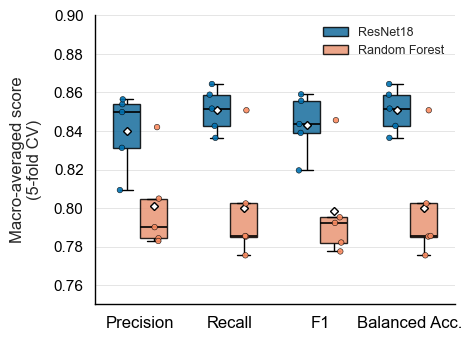

Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/2_drugSensitivity/figure3_model_comparison.png


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

metric_cols = list(METRIC_LABELS.keys())
combined_metrics = pd.concat(
    [resnet_fold_results[["model", "fold"] + metric_cols],
     rf_fold_results[["model", "fold"] + metric_cols]],
    ignore_index=True,
)

summary = combined_metrics.groupby("model")[metric_cols].agg(["mean", "std"])
print("Mean ± SD across 5 folds:")
print(summary)

plot_df = combined_metrics.melt(
    id_vars=["model", "fold"], value_vars=metric_cols, var_name="metric", value_name="value"
)
plot_df["Metric"] = plot_df["metric"].map(METRIC_LABELS)
plot_df["Model"] = plot_df["model"].map(MODEL_LABELS)
metric_order = list(METRIC_LABELS.values())
hue_order = list(MODEL_LABELS.values())
palette = {MODEL_LABELS[k]: v for k, v in MODEL_COLORS.items()}

# Nature-style box plots with every fold-level value visible
sns.set_theme(style="whitegrid", context="paper", font="Arial")
fig, ax = plt.subplots(figsize=(4.8, 3.5))
sns.boxplot(
    data=plot_df, x="Metric", y="value", hue="Model",
    order=metric_order, hue_order=hue_order, palette=palette,
    width=0.6, linewidth=1.0, showfliers=False, showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "white",
               "markeredgecolor": "black", "markersize": 4},
    boxprops={"edgecolor": "black", "linewidth": 1.0, "alpha": 0.85},
    whiskerprops={"color": "black", "linewidth": 1.0},
    capprops={"color": "black", "linewidth": 1.0},
    medianprops={"color": "black", "linewidth": 1.2}, ax=ax,
)
sns.stripplot(
    data=plot_df, x="Metric", y="value", hue="Model",
    order=metric_order, hue_order=hue_order, palette=palette,
    dodge=True, jitter=0.08, size=4, alpha=0.9,
    edgecolor="black", linewidth=0.4, legend=False, ax=ax, zorder=3,
)
ax.set_xlabel("")
ax.set_ylabel("Macro-averaged score\n(5-fold CV)", fontsize=12, labelpad=8)
ax.tick_params(axis="x", labelsize=12, colors="black")
ax.tick_params(axis="y", labelsize=11, colors="black")
ax.set_ylim(0.75, 0.9)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="", loc="upper right",
          fontsize=9, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.7)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(model_comparison_plot, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved {model_comparison_plot}")

### Pooled confusion matrices

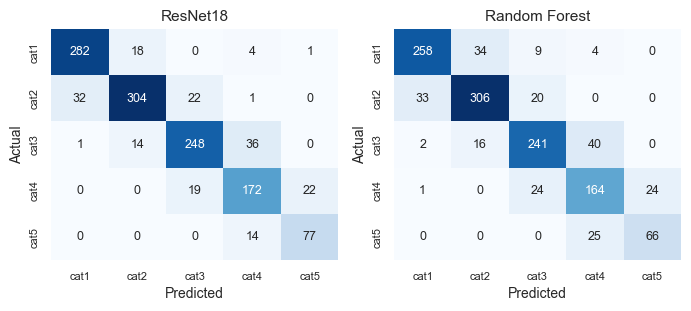

Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/2_drugSensitivity/figure3_confusion_matrices.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))
for ax, cm, title in zip(axes, [resnet_cm, rf_cm], ["ResNet18", "Random Forest"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=CATEGORIES, yticklabels=CATEGORIES,
                annot_kws={"fontsize": 9})
    ax.set_title(f"{title}", fontsize=11)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(confusion_plot, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved {confusion_plot}")

### Per-class performance comparison

Both pooled confusion matrices are built from out-of-fold predictions -- every one of the 1267 labeled figures was predicted exactly once, by whichever fold's model held it out.

          model category  precision    recall        f1  support
0      ResNet18     cat1   0.895238  0.924590  0.909677      305
1      ResNet18     cat2   0.904762  0.846797  0.874820      359
2      ResNet18     cat3   0.858131  0.829431  0.843537      299
3      ResNet18     cat4   0.757709  0.807512  0.781818      213
4      ResNet18     cat5   0.770000  0.846154  0.806283       91
5  RandomForest     cat1   0.877551  0.845902  0.861436      305
6  RandomForest     cat2   0.859551  0.852368  0.855944      359
7  RandomForest     cat3   0.819728  0.806020  0.812816      299
8  RandomForest     cat4   0.703863  0.769953  0.735426      213
9  RandomForest     cat5   0.733333  0.725275  0.729282       91


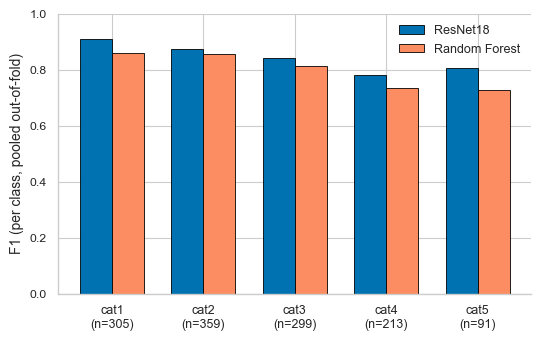

Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/2_drugSensitivity/figure3_per_class_comparison.png


In [4]:
from sklearn.metrics import precision_recall_fscore_support

per_class_rows = []
for model, pred_df in [("ResNet18", resnet_pred), ("RandomForest", rf_pred)]:
    precision, recall, f1, support = precision_recall_fscore_support(
        pred_df["true_label"], pred_df["pred_label"], labels=list(range(5)), zero_division=0
    )
    for i, cat in enumerate(CATEGORIES):
        per_class_rows.append({
            "model": model, "category": cat, "precision": precision[i],
            "recall": recall[i], "f1": f1[i], "support": int(support[i]),
        })
per_class_df = pd.DataFrame(per_class_rows)
print(per_class_df)

# F1 (not recall alone) so this is comparable to the macro-F1 headline metric above --
# recall alone rewards a model for over-predicting a class (catches more true positives
# but also more false positives), which is exactly what happens on cat5 below.
fig, ax = plt.subplots(figsize=(5.5, 3.5))
x = np.arange(len(CATEGORIES))
width = 0.35
for i, model in enumerate(["ResNet18", "RandomForest"]):
    sub = per_class_df[per_class_df["model"] == model].set_index("category").loc[CATEGORIES]
    ax.bar(x + (i - 0.5) * width, sub["f1"], width, label=MODEL_LABELS[model],
           color=MODEL_COLORS[model], edgecolor="black", linewidth=0.6)
support_labels = per_class_df[per_class_df["model"] == "ResNet18"].set_index("category").loc[CATEGORIES, "support"]
ax.set_xticks(x)
ax.set_xticklabels([f"{c}\n(n={n})" for c, n in zip(CATEGORIES, support_labels)], fontsize=9)
ax.set_ylabel("F1 (per class, pooled out-of-fold)", fontsize=10)
ax.set_ylim(0, 1.0)
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(per_class_plot, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved {per_class_plot}")

### RandomForest feature importance (SHAP, by class)

Per-class mean(|SHAP|), reloaded from the final model fit on all labeled figures (see `4-ml_randomforest.ipynb`) -- not recomputed here. Stacked in true category order (Highly Resistant -> Highly Sensitive), not SHAP's own default ordering (which sorts by each class's contribution size instead).

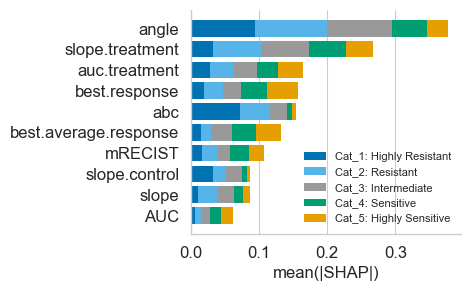

Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/2_drugSensitivity/figure3_rf_feature_importance.png


In [5]:
TOP_N_FEATURES = 10

fig, ax = plt.subplots(figsize=(4.8, 3))
ax.grid(axis="y", visible=False)  # keep vertical gridlines (read the SHAP axis), drop horizontal ones

plot_order = shap_by_class_df.index[:TOP_N_FEATURES][::-1]  # top N by total mean(|SHAP|), largest at top of barh
plot_labels = [
    f.replace("model_", "").replace("batch_", "").replace("mRECIST_encoded", "mRECIST")
    for f in plot_order
]
y_pos = np.arange(len(plot_order))

left = np.zeros(len(plot_order))
for cls, label, color in zip(CLASS_ORDER, CLASS_LABELS, CLASS_COLORS):
    values = shap_by_class_df.loc[plot_order, cls].values
    ax.barh(y_pos, values, left=left, color=color, label=label, edgecolor="none")
    left += values

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_labels)
ax.set_xlabel("mean(|SHAP|)", fontsize=12)
ax.set_ylabel("")
ax.tick_params(labelsize=12)
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(importance_plot, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved {importance_plot}")

### ResNet18 Grad-CAM: what the model attends to

One correctly-classified out-of-fold example per category (selected from `resnet18_cv_predictions.csv`, deterministically -- lowest `figure_id` per class among correct predictions). Each is explained by the checkpoint from the fold that actually held it out during training, so this is a genuine held-out prediction, not the model explaining an image it trained on. Grad-CAM is computed on `layer4` (ResNet18's last convolutional block) via forward/backward hooks -- no extra dependency beyond torch/torchvision.

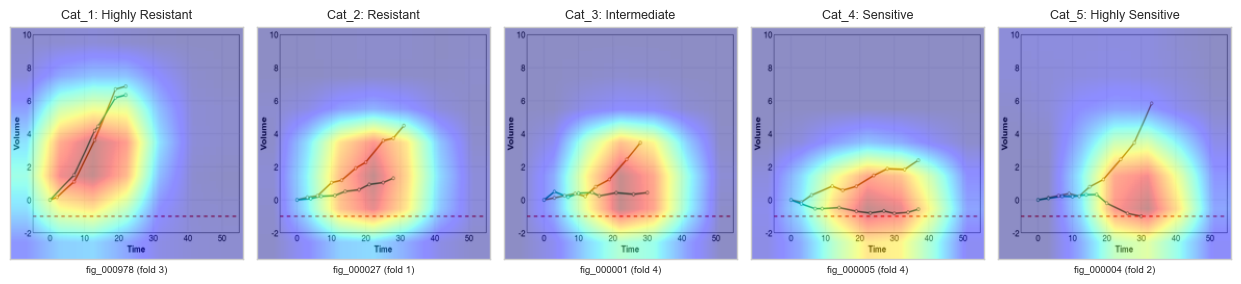

Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/2_drugSensitivity/figure3_gradcam.png


In [6]:
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

CLASS_NAMES = CLASS_ORDER  # Highly Resistant .. Highly Sensitive, same order as cat1..cat5

gpu_device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
image_dir = PROC_DIR / "images_clean"
gradcam_plot = RESULTS_DIR / "figure3_gradcam.png"

gradcam_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def build_resnet18(num_classes=5):
    model = models.resnet18(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(gpu_device)


def compute_gradcam(model, input_tensor, target_class, target_layer):
    """Standard Grad-CAM (Selvaraju et al. 2017) via forward/backward hooks."""
    activations, gradients = {}, {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    model.zero_grad()
    output = model(input_tensor)
    output[0, target_class].backward()

    h1.remove()
    h2.remove()

    acts = activations["value"][0]
    grads = gradients["value"][0]
    weights = grads.mean(dim=(1, 2))
    cam = torch.relu((weights[:, None, None] * acts).sum(dim=0))
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam.detach().cpu().numpy(), output.detach()


# One correctly-classified out-of-fold example per category, picked deterministically --
# except cat1, where we specifically pick the example with the smallest treatment/control
# divergence angle (batch_angle, RandomForest's top SHAP feature) so the panel shows genuinely
# near-overlapping curves -- the clearest visual signature of "Highly Resistant" (no drug effect).
correct_resnet_pred = resnet_pred[resnet_pred["true_label"] == resnet_pred["pred_label"]]

manifest = pd.read_csv(paths["datasets"] / "manifest.csv")
cat1_candidates = correct_resnet_pred[correct_resnet_pred["true_label"] == 0].merge(
    manifest[["figure_id", "batch_angle"]], on="figure_id", how="left"
)
cat1_best = cat1_candidates.loc[cat1_candidates["batch_angle"].abs().idxmin()]

gradcam_examples = [cat1_best] + [
    correct_resnet_pred[correct_resnet_pred["true_label"] == label].sort_values("figure_id").iloc[0]
    for label in range(1, 5)
]

fig, axes = plt.subplots(1, 5, figsize=(12.5, 3))

for ax, example in zip(axes, gradcam_examples):
    fold = int(example["fold"])
    figure_id = example["figure_id"]
    label = int(example["true_label"])

    model = build_resnet18()
    ckpt_path = resnet_dir / f"pdx_resnet18_fold{fold}_best.pth"
    model.load_state_dict(torch.load(ckpt_path, map_location=gpu_device))
    model.eval()

    pil_img = Image.open(image_dir / f"{figure_id}.png").convert("RGB")
    display_img = pil_img.resize((224, 224))
    input_tensor = gradcam_transform(pil_img).unsqueeze(0).to(gpu_device)

    cam, output = compute_gradcam(model, input_tensor, label, model.layer4)
    pred_label = int(output.argmax(dim=1).item())

    cam_img = Image.fromarray(np.uint8(cam * 255)).resize((224, 224), resample=Image.BILINEAR)
    cam_resized = np.array(cam_img) / 255.0

    ax.imshow(display_img)
    ax.imshow(cam_resized, cmap="jet", alpha=0.45)
    ax.set_title(f"Cat_{label + 1}: {CLASS_NAMES[label]}", fontsize=9)
    ax.set_xlabel(f"{figure_id} (fold {fold})", fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig(gradcam_plot, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved {gradcam_plot}")

### Results interpretation

Computed directly from the tables above -- not hardcoded -- so this stays correct if either model is retrained.

In [7]:
resnet_summary = summary.loc["ResNet18"]
rf_summary = summary.loc["RandomForest"]
resnet_cat5 = per_class_df[(per_class_df["model"] == "ResNet18") & (per_class_df["category"] == "cat5")].iloc[0]
rf_cat5 = per_class_df[(per_class_df["model"] == "RandomForest") & (per_class_df["category"] == "cat5")].iloc[0]

print(
    f"Macro-F1:          ResNet18 {resnet_summary[('test_macro_f1','mean')]:.3f} +/- {resnet_summary[('test_macro_f1','std')]:.3f}"
    f"   vs   RandomForest {rf_summary[('test_macro_f1','mean')]:.3f} +/- {rf_summary[('test_macro_f1','std')]:.3f}"
)
print(
    f"Balanced accuracy: ResNet18 {resnet_summary[('test_balanced_accuracy','mean')]:.3f} +/- {resnet_summary[('test_balanced_accuracy','std')]:.3f}"
    f"   vs   RandomForest {rf_summary[('test_balanced_accuracy','mean')]:.3f} +/- {rf_summary[('test_balanced_accuracy','std')]:.3f}"
)

better_f1 = "RandomForest" if rf_summary[("test_macro_f1", "mean")] > resnet_summary[("test_macro_f1", "mean")] else "ResNet18"
more_stable = "RandomForest" if rf_summary[("test_macro_f1", "std")] < resnet_summary[("test_macro_f1", "std")] else "ResNet18"
print(f"-> {better_f1} has the higher mean macro-F1; {more_stable} has the lower fold-to-fold SD (more stable).")

print(
    f"cat5 (rarest class, n={int(resnet_cat5['support'])}): "
    f"ResNet18 F1={resnet_cat5['f1']:.3f} (precision={resnet_cat5['precision']:.3f}, recall={resnet_cat5['recall']:.3f})"
    f"   vs   RandomForest F1={rf_cat5['f1']:.3f} (precision={rf_cat5['precision']:.3f}, recall={rf_cat5['recall']:.3f})"
)
better_cat5_f1 = "ResNet18" if resnet_cat5["f1"] > rf_cat5["f1"] else "RandomForest"
print(f"-> {better_cat5_f1} has the higher F1 on the rare class.")

higher_recall = "ResNet18" if resnet_cat5["recall"] > rf_cat5["recall"] else "RandomForest"
higher_precision = "ResNet18" if resnet_cat5["precision"] > rf_cat5["precision"] else "RandomForest"
if higher_recall != higher_precision:
    print(
        f"-> Precision/recall trade-off on cat5: {higher_recall} has higher recall (catches more true "
        f"cat5 cases) but {higher_precision} has higher precision (fewer other categories mislabeled "
        f"as cat5) -- F1 nets these out, and recall alone would have overstated {higher_recall}'s advantage."
    )

top_feature = shap_by_class_df.sum(axis=1).idxmax()
top_feature_total = shap_by_class_df.sum(axis=1).max()
print(f"Top RandomForest feature (SHAP): {top_feature} (total mean(|SHAP|) = {top_feature_total:.3f})")

Macro-F1:          ResNet18 0.843 +/- 0.016   vs   RandomForest 0.799 +/- 0.027
Balanced accuracy: ResNet18 0.851 +/- 0.011   vs   RandomForest 0.800 +/- 0.030
-> ResNet18 has the higher mean macro-F1; ResNet18 has the lower fold-to-fold SD (more stable).
cat5 (rarest class, n=91): ResNet18 F1=0.806 (precision=0.770, recall=0.846)   vs   RandomForest F1=0.729 (precision=0.733, recall=0.725)
-> ResNet18 has the higher F1 on the rare class.
Top RandomForest feature (SHAP): batch_angle (total mean(|SHAP|) = 0.378)
